In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from labellines import labelLine, labelLines
from libra_toolbox.tritium.model import (
    quantity_to_activity,
    activity_to_quantity,
)
from libra_toolbox.tritium.plotting import (
    ureg,
    plot_bars,
    plot_integrated_top_release,
    plot_integrated_wall_release,
    plot_irradiation,
    plot_sample_activity_top,
    plot_sample_activity_wall,
    plot_salt_inventory,
    plot_top_release,
    plot_wall_release,
)

ureg.mpl_formatter = "{:~P}"
# remove top and right axes by default
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
# set axis below true by default
plt.rcParams["axes.axisbelow"] = True

from tritium_model_errors import *

# Create outputs directory
os.makedirs('outputs', exist_ok=True)


/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-0-3 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-0-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-1-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-2-3 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-IV_2-2-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarn

57.3903740435172 becquerel 17.57022530771903 becquerel
0.555265973079106 0.3408242043613209
Processed data stored in ../../data/processed_data.json


/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-OV_2-9-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-OV_2-11-1 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-OV_2-11-2 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-OV_2-11-3 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: UserWarning: Activity of 1L-FLB-OV_2-11-4 is negative after substracting background. Setting to zero.
  warnings.warn(
/root/FLiBe-1L-run-2/analysis/tritium/tritium_model_errors.py:163: User

In [2]:
baby_model.run(100 * ureg.day)

/root/miniconda3/envs/flibe-1l-run-2/lib/python3.13/site-packages/scipy/integrate/_ivp/base.py:24: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(fun(t, y), dtype=dtype)


In [3]:
# Load temperature data
import sys
sys.path.append('../temperature')
from temperature_data import load_temperature_data

temp_data = load_temperature_data()

# Access temperature channels
dip_tc = temp_data['TC1']      # DIP TC
side_tc = temp_data['TC2']     # SIDE TC
ov_side_tc = temp_data['TC3']  # OV SIDE
furnace_tc = temp_data['TC4']  # FURNACE
dip_heater = temp_data['dip_heater']
filter_heater = temp_data['filter_heater']

print(f"Temperature channels loaded:")
print(f"  {dip_tc.tc_label}: {len(dip_tc.get_temperature())} data points")
print(f"  {side_tc.tc_label}: {len(side_tc.get_temperature())} data points")
print(f"  {ov_side_tc.tc_label}: {len(ov_side_tc.get_temperature())} data points")
print(f"  {furnace_tc.tc_label}: {len(furnace_tc.get_temperature())} data points")
print(f"  Dip heater: {len(dip_heater.get_setpoint_times())} setpoints")
print(f"  Filter heater: {len(filter_heater.get_setpoint_times())} setpoints")

# Read dip heater setpoints
setpoint_times = dip_heater.get_setpoint_times()
setpoint_values = dip_heater.get_setpoint_values()

# Read filter heater setpoints
filter_setpoint_times = filter_heater.get_setpoint_times()
filter_setpoint_values = filter_heater.get_setpoint_values()


Temperature channels loaded:
  DIP TC: 99873 data points
  SIDE TC: 99873 data points
  OV SIDE: 99873 data points
  FURNACE: 99873 data points
  Dip heater: 9 setpoints
  Filter heater: 9 setpoints


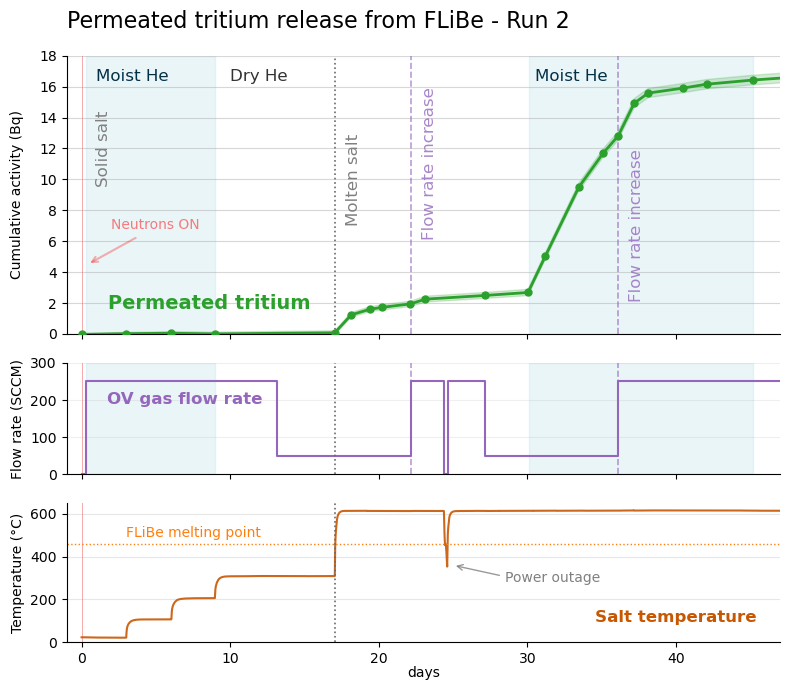

In [4]:
# ============================================================================
# DATA LOADING AND BASIC PLOTTING (cleaned and modular)
# ============================================================================
from datetime import datetime
import json

# --- helpers ---------------------------------------------------------------
def parse_dt(s):
    return datetime.strptime(s, "%m/%d/%Y %H:%M")

def to_days(dt, start):
    return (dt - start).total_seconds() / 86400.0

def load_general(path="../../data/general.json"):
    with open(path, "r") as fh:
        return json.load(fh)

def flow_rate_steps(flow_sample, start):
    times = [to_days(parse_dt(e["set_time"]), start) for e in flow_sample]
    values = [e["value"] for e in flow_sample]
    return times, values

def he_h2o_periods_from_switched(switched_list, start, end_limit):
    times = [to_days(parse_dt(e["gas_switch_time"]), start) for e in switched_list]
    periods = []
    for i, entry in enumerate(switched_list):
        if entry.get("type") == "He + H2O":
            start_day = times[i]
            end_day = times[i + 1] if i + 1 < len(times) else float(end_limit)
            periods.append((start_day, end_day))
    return periods

def find_setpoint_day(setpoints, target_value, start):
    # Prefer an increasing transition to the target value, otherwise first occurrence
    for i in range(1, len(setpoints)):
        prev = setpoints[i - 1]["value"]
        curr = setpoints[i]["value"]
        if curr == target_value and curr > prev:
            return to_days(parse_dt(setpoints[i]["set_time"]), start)
    for entry in setpoints:
        if entry.get("value") == target_value:
            return to_days(parse_dt(entry["set_time"]), start)
    return None

# --- figure setup ---------------------------------------------------------
fig, (ax1, ax_flow, ax2) = plt.subplots(
    3,
    1,
    figsize=(8, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 0.8, 1]},
)

# --- data used for plotting -----------------------------------------------
ov_cumulative = OV_stream_with_errors.get_cumulative_activity("total")
ov_errors = OV_stream_with_errors.get_cumulative_activity_errors("total")
times_walls = np.array([t.magnitude for t in replacement_times_walls])
ov_cumulative_mag = ov_cumulative.magnitude if hasattr(ov_cumulative, "magnitude") else ov_cumulative

general_data_plot = load_general()
run_start = parse_dt(general_data_plot["timestamps"]["run_start"]) 

# flow-change (first non-zero sample in cover_gas.flow_rate_sample)
cover_samples = general_data_plot.get("cover_gas", {}).get("flow_rate_sample", [])
flow_change_item = next((it for it in cover_samples if it.get("value") != 0), None)
flow_change_days = to_days(parse_dt(flow_change_item["set_time"]), run_start) if flow_change_item else None

# OV flow-rate step data
flow_rate_sample = general_data_plot.get("secondary_gas", {}).get("flow_rate_sample", [])
flow_rate_times, flow_rate_values = flow_rate_steps(flow_rate_sample, run_start)
flow_rate_times_step = flow_rate_times + [times_walls.max()]
flow_rate_values_step = flow_rate_values + ([flow_rate_values[-1]] if flow_rate_values else [0])

# He + H2O periods
switched_to = general_data_plot.get("secondary_gas", {}).get("switched_to", [])
he_h2o_periods = he_h2o_periods_from_switched(switched_to, run_start, times_walls.max())

# Mark selected flow changes (50 -> 250)
raw_flow_change_mark_times = []
for i in range(1, len(flow_rate_values)):
    if flow_rate_values[i - 1] == 50 and flow_rate_values[i] == 250:
        raw_flow_change_mark_times.append(flow_rate_times[i])

# Temperature data
temp_times = dip_tc.get_times_days()
temp_values = dip_tc.get_temperature()

# Heater setpoint event (first transition to 750 C)
dip_setpoints = general_data_plot.get("general_data", {}).get("temperature", {}).get("dip_setpoints", [])
heater_750_day = find_setpoint_day(dip_setpoints, 750, run_start)

# === plotting parameters (grouped and easy to edit) ======================
params = {
    "figsize": (8, 5.8),
    "grid_alpha": 0.5,
    "line_width": 2,
    "marker_size": 5,
    "fill_alpha": 0.2,
    "irradiation_alpha": 0.5,
    "ov_color": "tab:green",
    "ov_label_x": 1.8,
    "ov_label_y": 2,
    "ov_label_text": "Permeated tritium",
    "ov_label_fontsize": 14,
    "salt_melting_label_dx": 0.75,
    "salt_melting_label_y": 10,
    "salt_melting_label_fontsize": 12,
    "flow_increase_label_dx": 0.75,
    "flow_increase_label_y_positions": [11.0, 7.0],
    "flow_increase_label_fontsize": 12,
    "ax1_ylabel": "Cumulative activity (Bq)",
    "ax1_ylabel_pad": 11,
    "ax1_title": "Permeated tritium release from FLiBe - Run 2",
    "ax1_title_pad": 20,
    "ax1_title_fontsize": 16,
    "ax1_ylim_min": 0,
    "ax1_ylim_max": 18,
    "ax1_xlim_min": -1,
    "ax1_xlim_max": 47,
    "temp_color": "#C75702",
    "temp_linewidth": 1.5,
    "temp_alpha": 0.9,
    "temp_label_x": 40,
    "temp_label_y": 80,
    "temp_label_text": "Salt temperature",
    "temp_label_fontsize": 12,
    "neutrons_text_x": 2,
    "neutrons_text_y": 6.8,
    "neutrons_text": "Neutrons ON",
    "neutrons_text_color": "red",
    "neutrons_text_alpha": 0.5,
    "neutrons_text_fontsize": 10,
    "arrow_xy": (0.4, 4.5),
    "arrow_xytext": (3.8, 6.3),
    "arrow_color": "red",
    "arrow_alpha": 0.3,
    "arrow_lw": 1.5,
    "ax2_xlabel": "days",
    "ax2_xlabel_pad": 0,
    "ax2_ylabel": "Temperature (°C)",
    "ax2_grid_alpha": 0.3,
    "ax2_ylim_min": 0,
    "ax2_ylim_max": 650,
}

# Filter flow-change marks to plotting window (do not annotate events past x-axis max)
flow_change_mark_times = [t for t in raw_flow_change_mark_times if t <= params["ax1_xlim_max"]]

# --- Top plot: cumulative OV ---------------------------------------------
plt.sca(ax1)
ax1.grid(axis="y", alpha=params["grid_alpha"])
for start_day, end_day in he_h2o_periods:
    ax1.axvspan(start_day, end_day, color="lightblue", alpha=0.25, zorder=0)
ax1.plot(times_walls, ov_cumulative_mag, color=params["ov_color"], linewidth=params["line_width"], marker="o", markersize=params["marker_size"], zorder=3)
ax1.fill_between(times_walls, ov_cumulative_mag - ov_errors, ov_cumulative_mag + ov_errors, color=params["ov_color"], alpha=params["fill_alpha"], zorder=2)
for mark_day in flow_change_mark_times:
    ax1.axvline(x=mark_day, color="tab:purple", linestyle="--", linewidth=1.2, alpha=0.65, zorder=1)

if heater_750_day is not None:
    for _ax in (ax1, ax_flow, ax2):
        _ax.axvline(x=heater_750_day, color="dimgray", linestyle=":", linewidth=1.2, alpha=1, zorder=6)
    ax1.text(0.2 + params["salt_melting_label_dx"], 2 + params["salt_melting_label_y"], "Solid salt", color="gray", fontsize=params["salt_melting_label_fontsize"], rotation=90, va="center", ha="left", zorder=7)
    ax1.text(heater_750_day + params["salt_melting_label_dx"], params["salt_melting_label_y"], "Molten salt", color="gray", fontsize=params["salt_melting_label_fontsize"], rotation=90, va="center", ha="left", zorder=7)

for idx, mark_day in enumerate(flow_change_mark_times):
    label_y = params["flow_increase_label_y_positions"][idx] if idx < len(params["flow_increase_label_y_positions"]) else params["flow_increase_label_y_positions"][-1]
    ax1.text(mark_day + params["flow_increase_label_dx"], label_y, "Flow rate increase", color="tab:purple", alpha=0.8, fontsize=params["flow_increase_label_fontsize"], rotation=90, va="center", ha="left", zorder=7)

ax1.text(params["ov_label_x"], params["ov_label_y"], params["ov_label_text"], color=params["ov_color"], va="center", fontsize=params["ov_label_fontsize"], fontweight="bold", zorder=4)
ax1.text(1, 16.2, "Moist He", color="#023047", fontsize=12, ha="left", va="bottom", zorder=4)
ax1.text(10, 16.2, "Dry He", color="black", alpha=0.8, fontsize=12, ha="left", va="bottom", zorder=4)
ax1.text(30.5, 16.2, "Moist He", color="#023047", fontsize=12, ha="left", va="bottom", zorder=4)
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params["irradiation_alpha"]) 
ax1.set_ylabel(params["ax1_ylabel"], labelpad=params["ax1_ylabel_pad"], fontsize=10)
ax1.set_title(params["ax1_title"], loc="left", pad=params["ax1_title_pad"], fontsize=params["ax1_title_fontsize"])
ax1.set_ylim(params["ax1_ylim_min"], params["ax1_ylim_max"])
ax1.set_xlim(params["ax1_xlim_min"], params["ax1_xlim_max"])

# --- Middle plot: OV gas flow ------------------------------------------------
plt.sca(ax_flow)
ax_flow.grid(axis="y", alpha=0.2)
ax_flow.step(flow_rate_times_step, flow_rate_values_step, where="post", color="tab:purple", lw=1.5)
for start_day, end_day in he_h2o_periods:
    ax_flow.axvspan(start_day, end_day, color="lightblue", alpha=0.25, zorder=0)
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params["irradiation_alpha"]) 
ax_flow.text(1.7, 180, "OV gas flow rate", color="tab:purple", fontsize=12, ha="left", va="bottom", fontweight="bold", zorder=6)
for mark_day in flow_change_mark_times:
    ax_flow.axvline(x=mark_day, color="tab:purple", linestyle="--", linewidth=1.2, alpha=0.65, zorder=3)
ax_flow.set_ylabel("Flow rate (SCCM)", fontsize=10)
ax_flow.set_xlim(params["ax1_xlim_min"], params["ax1_xlim_max"])
ax_flow.set_ylim(bottom=0, top=300)

# --- Bottom plot: Temperature profile ---------------------------------------
plt.sca(ax2)
ax2.plot(temp_times, temp_values, linewidth=params["temp_linewidth"], alpha=params["temp_alpha"], color=params["temp_color"]) 
ax2.axhline(y=459, color="tab:orange", linestyle=":", linewidth=1)
ax2.text(3, 490, r"FLiBe melting point", color="tab:orange", fontsize=10)
ax2.text(params["temp_label_x"], params["temp_label_y"], params["temp_label_text"], color=params["temp_color"], va="bottom", ha="center", fontsize=params["temp_label_fontsize"], fontweight="bold")
ax1.text(params["neutrons_text_x"], params["neutrons_text_y"], params["neutrons_text"], color=params["neutrons_text_color"], alpha=params["neutrons_text_alpha"], fontsize=params["neutrons_text_fontsize"]) 
ax1.annotate("", xy=params["arrow_xy"], xytext=params["arrow_xytext"], arrowprops=dict(arrowstyle="->", color=params["arrow_color"], alpha=params["arrow_alpha"], lw=params["arrow_lw"]))
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params["irradiation_alpha"]) 
ax2.text(28.5, 280, r"Power outage", color="gray", fontsize=10)
ax2.annotate("", xy=(25, 360), xytext=(28.3, 310), arrowprops=dict(arrowstyle="->", color="gray", alpha=0.8, lw=1))
ax2.set_xlabel(params["ax2_xlabel"], labelpad=params["ax2_xlabel_pad"], fontsize=10)
ax2.set_ylabel(params["ax2_ylabel"]) 
ax2.grid(axis="y", alpha=params["ax2_grid_alpha"]) 
ax2.set_xlim(params["ax1_xlim_min"], params["ax1_xlim_max"]) 
ax2.set_ylim(params["ax2_ylim_min"], params["ax2_ylim_max"]) 

# Save and display figure
plt.tight_layout()
plt.savefig('outputs/OV_details_run_2.pdf', bbox_inches='tight')
plt.savefig('outputs/OV_details_run_2.svg', bbox_inches='tight')
plt.savefig('outputs/OV_details_run_2.png', bbox_inches='tight')
plt.show()


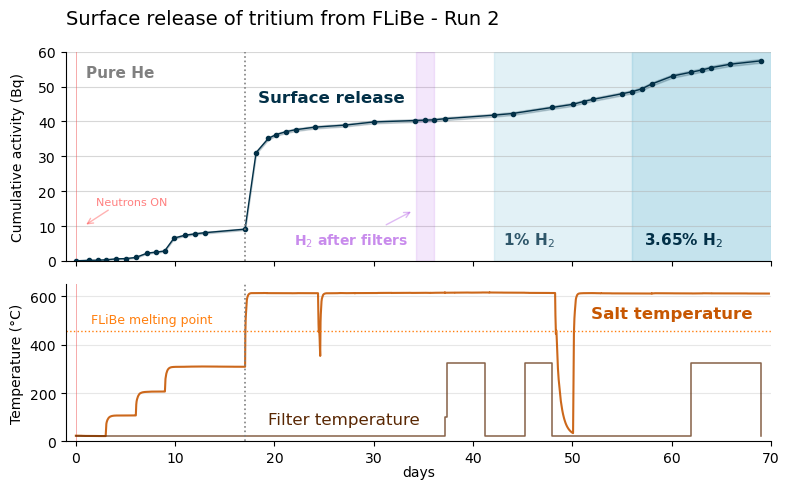

In [5]:
# ============================================================================
# DATA LOADING AND BASIC PLOTTING (refactored for readability)
# ============================================================================
from datetime import datetime
import json


def parse_time(value):
    return datetime.strptime(value, "%m/%d/%Y %H:%M")


def days_since(start_time, event_time):
    return (event_time - start_time).total_seconds() / 86400.0


def first_nonzero_cover_flow_day(general_data_plot):
    run_start_local = parse_time(general_data_plot["timestamps"]["run_start"])
    samples = general_data_plot["cover_gas"]["flow_rate_sample"]
    first_nonzero = next((item for item in samples if item["value"] != 0), None)
    if first_nonzero is None:
        return run_start_local, None
    flow_day = days_since(run_start_local, parse_time(first_nonzero["set_time"]))
    return run_start_local, flow_day


def extract_h2_window_days(cover_switch_days):
    if len(cover_switch_days) >= 2:
        return cover_switch_days[0].magnitude, cover_switch_days[1].magnitude
    return None, None


# --- Load data required for plotting ----------------------------------------
with open("../../data/general.json", "r") as fh:
    general_data_plot = json.load(fh)

run_start, flow_change_days = first_nonzero_cover_flow_day(general_data_plot)
h2_start_days, h2_end_days = extract_h2_window_days(cover_gas_switch_deltatimes)
cover_gas_switches = general_data_plot.get("cover_gas", {}).get("switched_to", [])
cover_gas_1pct_day = next((to_days(parse_time(item["gas_switch_time"]), run_start) for item in cover_gas_switches if item.get("type") == "He + 1% H2" and item.get("gas_switch_time") is not None), None)
cover_gas_365_day = next((to_days(parse_time(item["gas_switch_time"]), run_start) for item in cover_gas_switches if item.get("type") == "He + 3.65% H2" and item.get("gas_switch_time") is not None and cover_gas_1pct_day is not None and to_days(parse_time(item["gas_switch_time"]), run_start) > cover_gas_1pct_day), None)

iv_cumulative = IV_stream_with_errors.get_cumulative_activity("total")
iv_errors = IV_stream_with_errors.get_cumulative_activity_errors("total")

times_top = np.array([t.magnitude for t in replacement_times_top])
iv_cumulative_mag = iv_cumulative.magnitude if hasattr(iv_cumulative, "magnitude") else iv_cumulative

temp_times = dip_tc.get_times_days()
temp_values = dip_tc.get_temperature()

# --- Plot parameters ---------------------------------------------------------
params = {
    "figure": {"size": (8, 5), "irradiation_alpha": 0.5},
    "release": {
        "grid_alpha": 0.5,
        "line_width": 1,
        "marker_size": 3,
        "fill_alpha": 0.2,
        "color": "#023047",
        "label_text": "Surface release",
        "label_x": 18.3,
        "label_y": 46.8,
        "label_fontsize": 12,
        "ylabel": "Cumulative activity (Bq)",
        "ylabel_pad": 10,
        "title": "Surface release of tritium from FLiBe - Run 2",
        "title_pad": 20,
        "title_fontsize": 14,
        "ylim": (0, 60),
        "xlim": (-1, 70),
        "neutrons_text": "Neutrons ON",
        "neutrons_text_x": 2,
        "neutrons_text_y": 16,
        "neutrons_text_color": "red",
        "neutrons_text_alpha": 0.5,
        "neutrons_text_fontsize": 8,
        "arrow_xy": (0.8, 10),
        "arrow_xytext": (3.5, 15),
        "arrow_color": "red",
        "arrow_alpha": 0.3,
        "arrow_lw": 1,
    },
    "flow_change": {
        "color": "gray",
        "linestyle": "--",
        "linewidth": 1.5,
        "alpha": 0.8,
    },
    "h2": {"span_color": "#9319da", "span_alpha": 0.10},
    "temperature": {
        "line_color": "#C75702",
        "line_width": 1.5,
        "line_alpha": 0.9,
        "label_text": "Salt temperature",
        "label_x": 60,
        "label_y": 500,
        "label_fontsize": 12,
        "melt_line_y": 459,
        "melt_line_color": "tab:orange",
        "melt_label_x": 1.5,
        "melt_label_y": 490,
        "melt_label_text": r"FLiBe melting point",
        "power_label_x": 25.5,
        "power_label_y": 250,
        "power_label_text": r"Power outage",
        "power_arrow_xy": (25.5, 385),
        "power_arrow_xytext": (28, 310),
        "xlabel": "days",
        "xlabel_pad": 0,
        "ylabel": "Temperature (°C)",
        "grid_alpha": 0.3,
        "ylim": (0, 650),
    },
}

# --- Create figure -----------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=params["figure"]["size"],
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1.5]},
)

# --- Top plot: tritium release ----------------------------------------------
release_cfg = params["release"]
flow_cfg = params["flow_change"]

ax1.grid(axis="y", alpha=release_cfg["grid_alpha"])
ax1.plot(
    times_top,
    iv_cumulative_mag,
    color=release_cfg["color"],
    linewidth=release_cfg["line_width"],
    marker="o",
    markersize=release_cfg["marker_size"],
)
ax1.fill_between(
    times_top,
    iv_cumulative_mag - iv_errors,
    iv_cumulative_mag + iv_errors,
    color=release_cfg["color"],
    alpha=release_cfg["fill_alpha"],
)

if cover_gas_1pct_day is not None and cover_gas_365_day is not None:
    ax1.axvspan(cover_gas_1pct_day, cover_gas_365_day, color="lightblue", alpha=0.35, zorder=0)
    ax1.axvspan(cover_gas_365_day, release_cfg["xlim"][1], color="lightblue", alpha=0.7, zorder=0)

if h2_start_days is not None and h2_end_days is not None:
    ax1.axvspan(
        h2_start_days,
        h2_end_days,
        color=params["h2"]["span_color"],
        alpha=params["h2"]["span_alpha"],
    )

ax1.text(
    release_cfg["label_x"],
    release_cfg["label_y"],
    release_cfg["label_text"],
    color=release_cfg["color"],
    va="center",
    fontsize=release_cfg["label_fontsize"],
    fontweight="bold",
)

ax1.text(params["release"]["neutrons_text_x"], params["release"]["neutrons_text_y"], params["release"]["neutrons_text"], color=params["release"]["neutrons_text_color"], alpha=params["release"]["neutrons_text_alpha"], fontsize=params["release"]["neutrons_text_fontsize"]) 
ax1.annotate("", xy=params["release"]["arrow_xy"], xytext=params["release"]["arrow_xytext"], arrowprops=dict(arrowstyle="->", color=params["release"]["arrow_color"], alpha=params["release"]["arrow_alpha"], lw=params["release"]["arrow_lw"]))

ax1.text(1, 52, "Pure He", color="gray", fontsize=11, ha="left", va="bottom", fontweight="bold", zorder=4)
ax1.text(43, 3.5, "1% H$_{2}$", color="#023047", alpha=0.8, fontsize=11, ha="left", va="bottom", fontweight="bold", zorder=4)
ax1.text(57.2, 3.5, "3.65% H$_{2}$", color="#023047", fontsize=11, ha="left", va="bottom", fontweight="bold", zorder=4)

ax1.text(22, 3.5, "H$_{2}$ after filters", color="#9319da", alpha=0.5, fontsize=10, ha="left", va="bottom", fontweight="bold", zorder=7)
ax1.annotate("", xy=(34, 14.5), xytext=(31, 10), arrowprops=dict(arrowstyle="->", color="#9319da", alpha=0.3, lw=1), zorder=7)
if heater_750_day is not None:
    for _ax in (ax1, ax_flow, ax2):
        _ax.axvline(x=heater_750_day, color="gray", linestyle=":", linewidth=1.2, alpha=1, zorder=6)
plt.sca(ax1)
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params["figure"]["irradiation_alpha"])
ax1.set_ylabel(release_cfg["ylabel"], labelpad=release_cfg["ylabel_pad"])
ax1.set_title(
    release_cfg["title"],
    loc="left",
    pad=release_cfg["title_pad"],
    fontsize=release_cfg["title_fontsize"],
)
ax1.set_ylim(*release_cfg["ylim"])
ax1.set_xlim(*release_cfg["xlim"])

# --- Bottom plot: temperature profile ---------------------------------------
temp_cfg = params["temperature"]

ax2.plot(
    temp_times,
    temp_values,
    linewidth=temp_cfg["line_width"],
    alpha=temp_cfg["line_alpha"],
    color=temp_cfg["line_color"],
)
# Plot filter heater setpoints as a step function (brown),
# using the same linewidth and alpha as the salt temperature line.
try:
    ax2.step(filter_setpoint_times, filter_setpoint_values, where="post", color="#5A2804", linewidth=0.75*temp_cfg["line_width"], alpha=0.8*temp_cfg["line_alpha"])
except NameError:
    # filter setpoint variables not defined in this scope; skip plotting
    pass
ax2.axhline(
    y=temp_cfg["melt_line_y"],
    color=temp_cfg["melt_line_color"],
    linestyle=":",
    linewidth=1,
)
ax2.text(
    temp_cfg["melt_label_x"],
    temp_cfg["melt_label_y"],
    temp_cfg["melt_label_text"],
    color=temp_cfg["melt_line_color"],
    fontsize=9,
)
ax2.text(
    temp_cfg["label_x"],
    temp_cfg["label_y"],
    temp_cfg["label_text"],
    color=temp_cfg["line_color"],
    va="bottom",
    ha="center",
    fontsize=temp_cfg["label_fontsize"],
    fontweight="bold",
)
ax2.text(27, 60, "Filter temperature", color="#5A2804", va="bottom", ha="center", fontsize=temp_cfg["label_fontsize"])
plt.sca(ax2)
plot_irradiation(baby_model, facecolor="#EF5B5B", alpha=params["figure"]["irradiation_alpha"])

ax2.set_xlabel(temp_cfg["xlabel"], labelpad=temp_cfg["xlabel_pad"], fontsize=10)
ax2.set_ylabel(temp_cfg["ylabel"])
ax2.grid(axis="y", alpha=temp_cfg["grid_alpha"])
ax2.set_ylim(*temp_cfg["ylim"])

# --- Save and show -----------------------------------------------------------
plt.tight_layout()
plt.savefig("outputs/surface_release_run_2.pdf", bbox_inches="tight")
plt.savefig("outputs/surface_release_run_2.svg", bbox_inches="tight")
plt.savefig("outputs/surface_release_run_2.png", bbox_inches="tight")
plt.show()